In [1]:
!pip install tensorflow numpy matplotlib jupyter opencv-python
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os
import cv2
import numpy as np

DATASET_PATH = r'C:\Coolyeah\Semester 4\TUBES AI LAB\archive\plantvillage dataset\color'
IMG_HEIGHT = 128        
IMG_WIDTH = 128
BATCH_SIZE = 32
# Jumlah putaran belajar 
EPOCHS = 10

print("Versi TensorFlow:", tf.__version__)
print("Pastikan folder dataset sudah sesuai path:", os.path.exists(DATASET_PATH))

Versi TensorFlow: 2.20.0
Pastikan folder dataset sudah sesuai path: True


In [3]:
# 1. Load Data untuk Latihan (Training) - 80% Data
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,   
    subset="training",       
    seed=123,                
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

# 2. Load Data untuk Ujian (Validation) - 20% Data
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",     # Ini bagian Validation
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

# 3. Simpan nama kelas (Penyakit)
class_names = train_ds.class_names
print("\nNama Kelas/Penyakit yang ditemukan:", class_names)

Found 54304 files belonging to 38 classes.
Using 43444 files for training.
Found 54304 files belonging to 38 classes.
Using 10860 files for validation.

Nama Kelas/Penyakit yang ditemukan: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato_

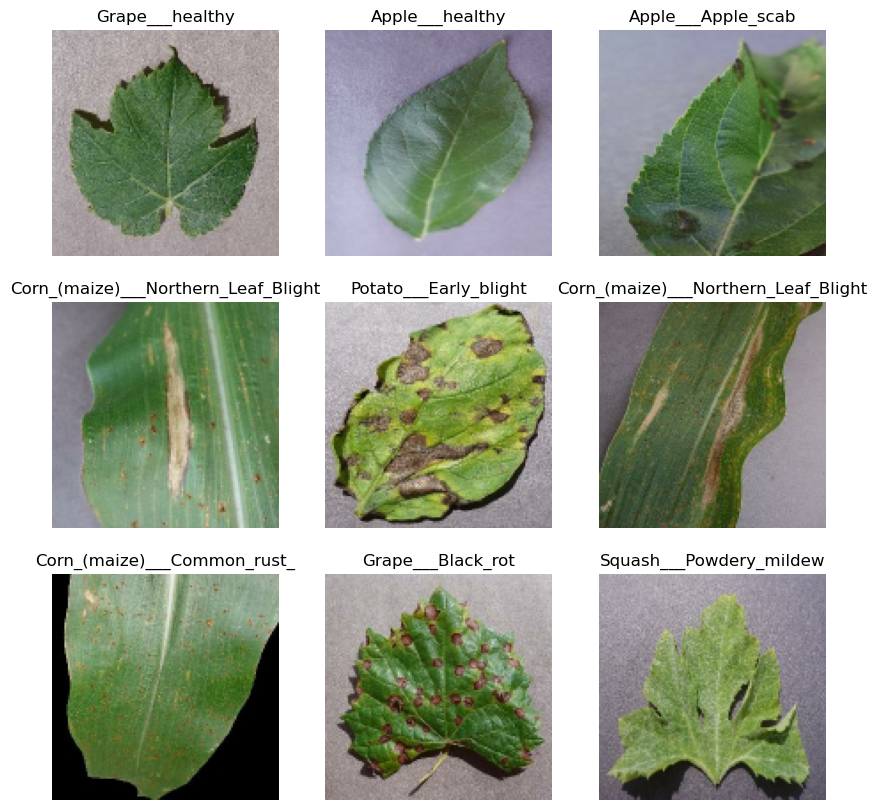

In [4]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [5]:
num_classes = len(class_names)

model = models.Sequential([
    # 1. Preprocessing Layer
    layers.Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # 2. Convolutional Layers (Feature Extraction)
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # 3. Fully Connected Layers (Classification)
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # Mencegah overfitting 
    layers.Dense(num_classes, activation='softmax')  # Output layer
])

# Kompilasi Model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(
                  from_logits=False),
              metrics=['accuracy'])

model.summary()

c:\PythonSGInstallation\envs\sg_env\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,125,766 (8.11 MB)

 Trainable params: 2,125,766 (8.11 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 184s 134ms/step - accuracy: 0.5472 - loss: 1.6156 - val_accuracy: 0.7909 - val_loss: 0.6996
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 110s 81ms/step - accuracy: 0.7330 - loss: 0.8752 - val_accuracy: 0.8682 - val_loss: 0.4313
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 108s 80ms/step - accuracy: 0.7922 - loss: 0.6529 - val_accuracy: 0.8967 - val_loss: 0.3234
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 107s 79ms/step - accuracy: 0.8262 - loss: 0.5420 - val_accuracy: 0.9060 - val_loss: 0.2934
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 106s 78ms/step - accuracy: 0.8510 - loss: 0.4590 - val_accuracy: 0.8873 - val_loss: 0.3490
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 103s 76ms/step - accuracy: 0.8710 - loss: 0.3943 - val_accuracy: 0.9178 - val_loss: 0.2707
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 104s 76ms/step - accuracy: 0.8840 - loss: 0.3535 - val_accuracy: 0.9290 - val_loss: 0.2194
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 105s 78ms/step - accuracy:

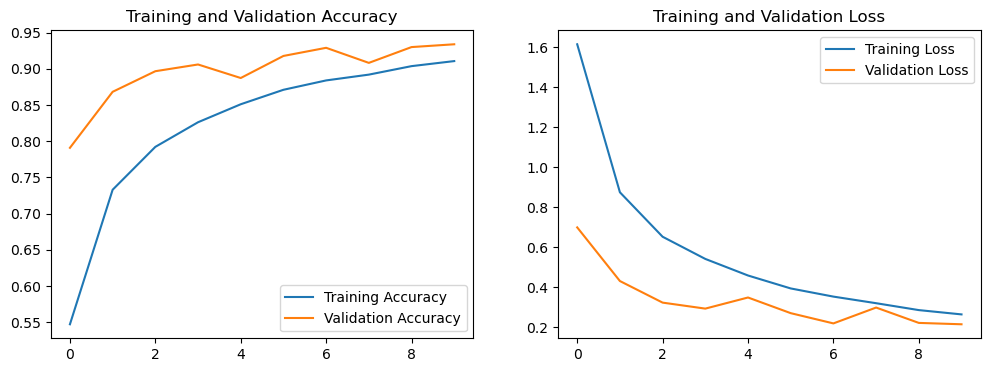

In [7]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [8]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Sedang mengevaluasi model pada data validasi. Mohon tunggu...")

y_true = []
y_pred = []

for images, labels in val_ds:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))

print("Evaluasi selesai!")

Sedang mengevaluasi model pada data validasi. Mohon tunggu...
Evaluasi selesai!



=== CLASSIFICATION REPORT ===
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.68      0.90      0.78       120
                                 Apple___Black_rot       0.96      0.92      0.94       124
                          Apple___Cedar_apple_rust       0.98      0.79      0.87        56
                                   Apple___healthy       0.89      0.87      0.88       348
                               Blueberry___healthy       0.97      0.94      0.96       318
          Cherry_(including_sour)___Powdery_mildew       0.96      0.93      0.94       208
                 Cherry_(including_sour)___healthy       0.98      0.93      0.95       147
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.79      0.66      0.72       109
                       Corn_(maize)___Common_rust_       0.99      0.99      0.99       238
               Corn_(maize)___Northern_Leaf_Blig

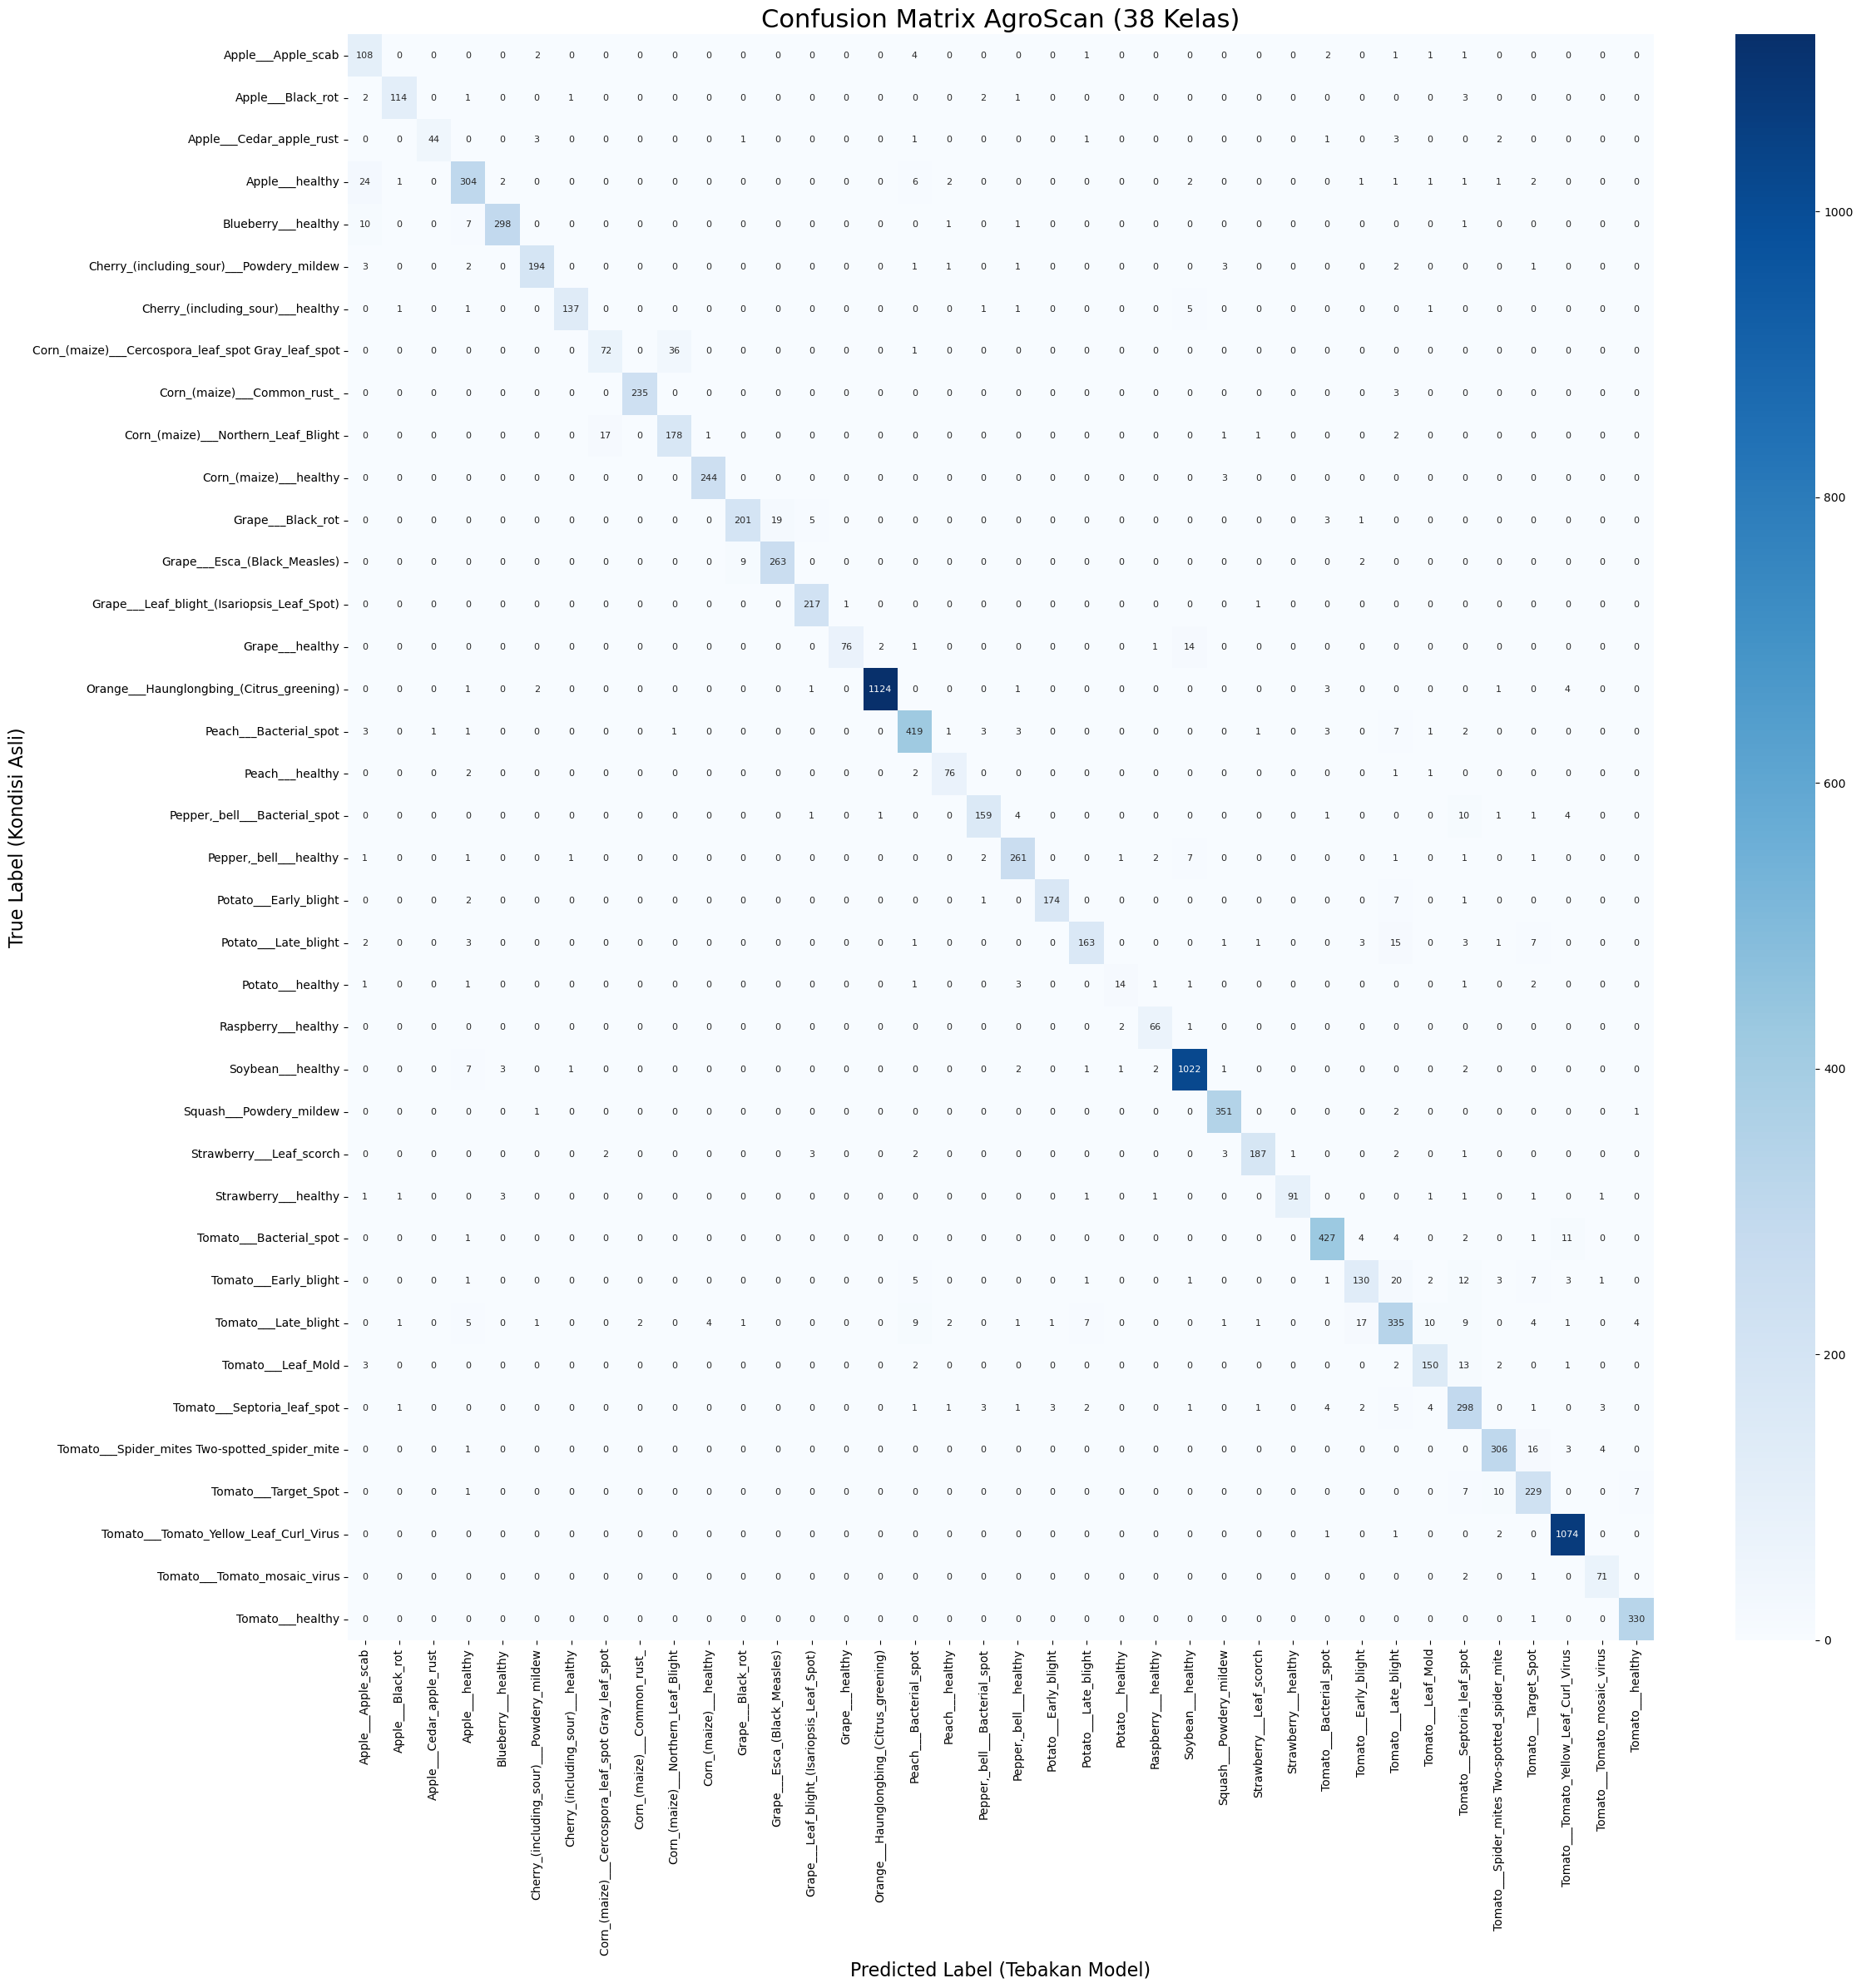

In [9]:
y_true = []
y_pred = []

for images, labels in val_ds:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))

# 2. Menampilkan Precision, Recall, F1-Score
print("\n=== CLASSIFICATION REPORT ===")
# Ini akan memunculkan teks tabel metrik evaluasi
print(classification_report(y_true, y_pred, target_names=class_names))

# 3. Menggambar Confusion Matrix (DENGAN ANGKA)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(24, 24))  # Ukuran kanvas diperbesar agar 38 kelas muat

# annot=True akan memunculkan angka. annot_kws mengatur ukuran font angkanya.
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 8})

plt.title('Confusion Matrix AgroScan (38 Kelas)', fontsize=22)
plt.ylabel('True Label (Kondisi Asli)', fontsize=16)
plt.xlabel('Predicted Label (Tebakan Model)', fontsize=16)
plt.xticks(rotation=90)
plt.tight_layout()  # Agar label tidak terpotong saat di-save/screenshot
plt.show()

In [10]:
model.save('model_agroscan.keras')
print("Model berhasil disimpan sebagai 'model_agroscan.h5'")

Model berhasil disimpan sebagai 'model_agroscan.h5'
